DATA6000 — Random Forest Regression (ML Component)
Monthly BOM Rainfall → FY Aggregation → Production Risk

STEP 3 — LOADING MONTHLY RAINFALL DATA
Excel not found — using hardcoded monthly data

Monthly observations: 60 (2020–2024)
Rainfall range: 16.5mm – 210.0mm

Average by month:
  Jan:   47.0mm  █████
  Feb:   26.4mm  ███
  Mar:   30.6mm  ███
  Apr:   58.8mm  ███████
  May:   71.4mm  ████████
  Jun:  124.1mm  ███████████████
  Jul:  148.3mm  ██████████████████
  Aug:  149.9mm  ██████████████████
  Sep:  101.2mm  ████████████
  Oct:   80.4mm  ██████████
  Nov:   66.2mm  ████████
  Dec:   46.8mm  █████

STEP 4 — FEATURE ENGINEERING
Training samples: 48  |  Features: 12

STEP 5 — TRAIN RANDOM FOREST REGRESSION
  Cross-validation R² (5-fold): 0.5281 ± 0.0972
  Cross-validation RMSE:        31.04mm
  Training RMSE:  15.29mm
  Training MAE:   11.00mm
  Training R²:    0.8874

Top feature importances:
  Rain_Lag6      0.1689  ████████████████
  Rain_Lag12     0.1664  ████████████████
  Se

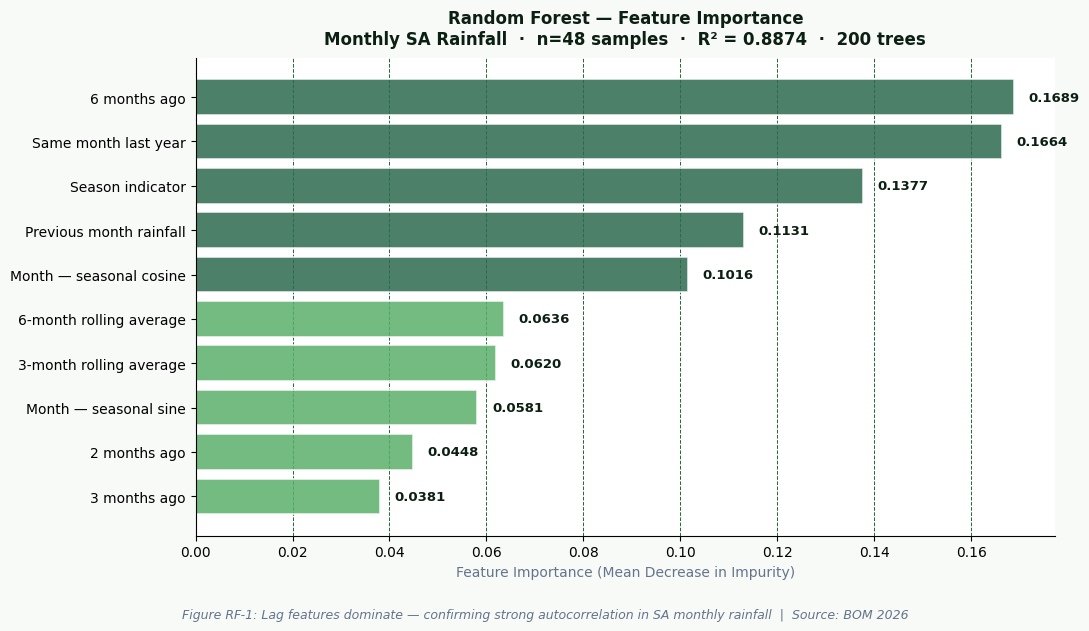

Saved: ChartRF_FeatureImportance.png


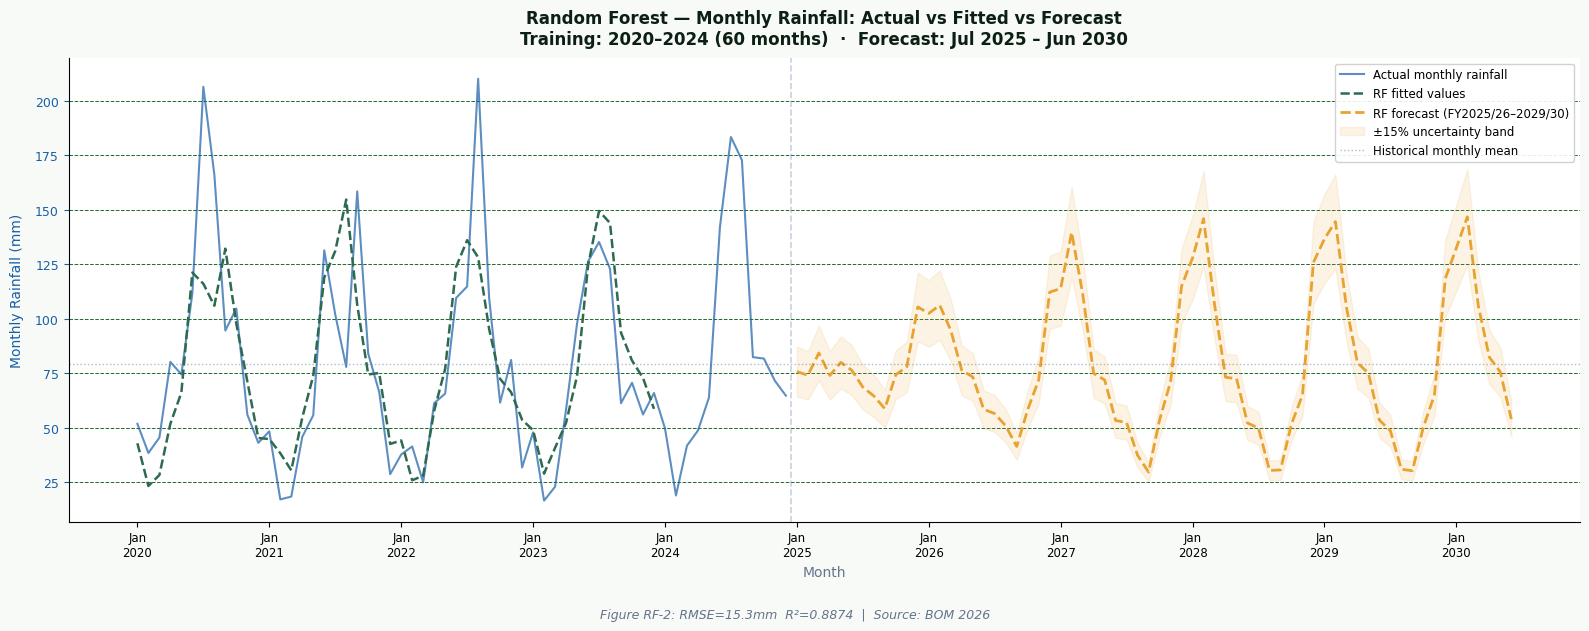

Saved: ChartRF_MonthlyForecast.png


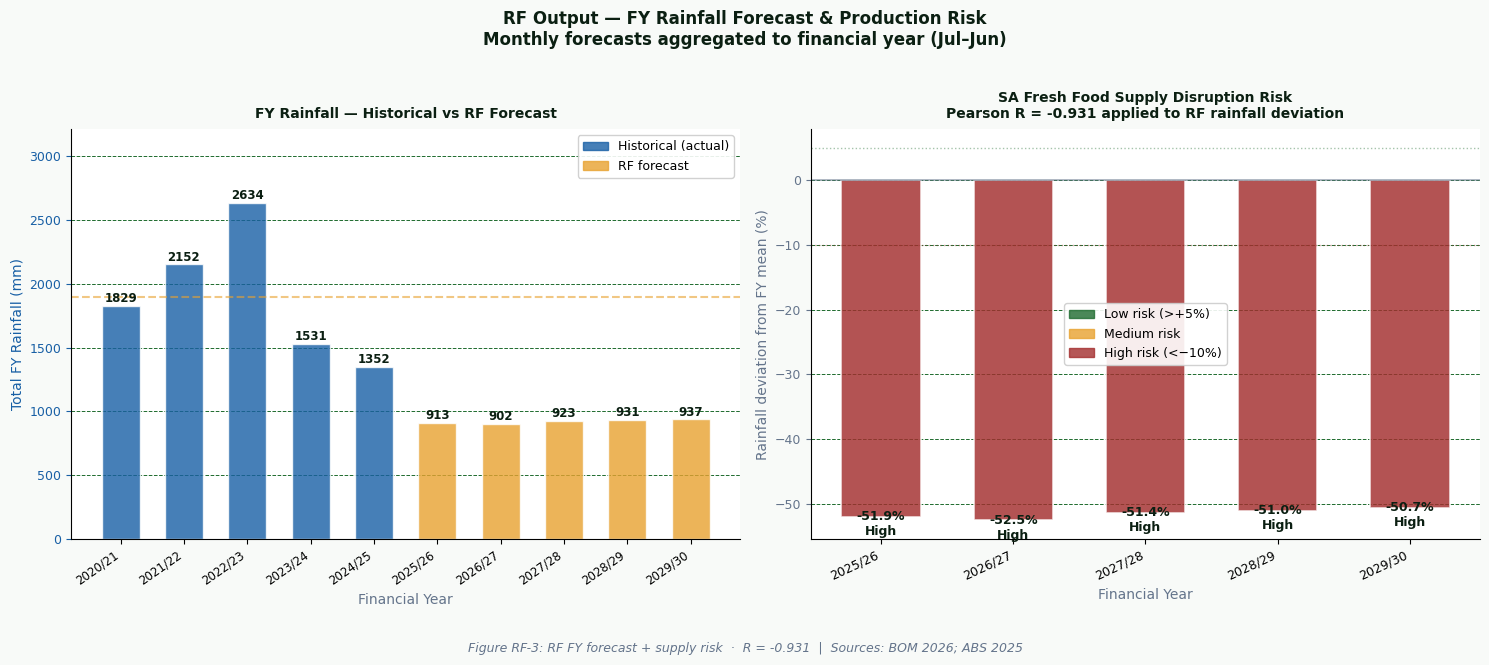

Saved: ChartRF_ProductionRisk.png

RANDOM FOREST RESULTS SUMMARY

Algorithm:      Random Forest Regression
Training data:  Monthly BOM rainfall — 60 observations (2020–2024)
Features:       12 engineered (lags, rolling avg, cyclical month encoding)
Trees:          200  ·  max_depth=6  ·  max_features=sqrt

Performance:
  CV R² (5-fold): 0.5281 ± 0.0972
  CV RMSE:        31.04mm
  Train RMSE:     15.29mm
  Train R²:       0.8874

FY Forecast + Risk:
  2025/26: 913mm  (-51.9%)  → High supply risk
  2026/27: 902mm  (-52.5%)  → High supply risk
  2027/28: 923mm  (-51.4%)  → High supply risk
  2028/29: 931mm  (-51.0%)  → High supply risk
  2029/30: 937mm  (-50.7%)  → High supply risk

Charts saved:
  ChartRF_FeatureImportance.png
  ChartRF_MonthlyForecast.png
  ChartRF_ProductionRisk.png

Role in framework:
  Statistical:     Pearson R, Regression, ARIMA, Holt-Winters, Prophet
  Machine Learning: Random Forest ← this file
  Link:            RF forecasts rainfall → R=-0.931 → production risk

In [1]:
# ============================================================
# DATA6000 Capstone — SA Retail Fresh Food Supply Disruption
# Random Forest Regression — Machine Learning Component
# Applied to monthly BOM rainfall data (72 observations)
# Forecasts monthly rainfall → aggregates to FY → production risk
# Google Colab Ready
# ============================================================

# ── STEP 1: Install ──────────────────────────────────────────
# !pip install scikit-learn matplotlib pandas numpy openpyxl seaborn

# ── STEP 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble         import RandomForestRegressor
from sklearn.model_selection  import cross_val_score, KFold
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

print("=" * 65)
print("DATA6000 — Random Forest Regression (ML Component)")
print("Monthly BOM Rainfall → FY Aggregation → Production Risk")
print("=" * 65)

# ── COLOUR PALETTE ───────────────────────────────────────────
C_RF    = '#2D6A4F'
C_FORE  = '#E8A230'
C_RAIN  = '#185FA5'
C_RISK  = '#A32D2D'
C_BG    = '#F8FAF8'
C_TITLE = '#0B1F12'
C_MUTED = '#64748B'
C_GRID  = (30/255, 107/255, 46/255, 0.07)

# ============================================================
# STEP 3 — LOAD MONTHLY RAINFALL DATA
# ============================================================
print("\n" + "=" * 65)
print("STEP 3 — LOADING MONTHLY RAINFALL DATA")
print("=" * 65)

try:
    xl = pd.read_excel('/content/Final_Dataset.xlsx', sheet_name=None)
    EXCEL_LOADED = True
    print(f"Excel loaded: {list(xl.keys())}")
except Exception:
    xl = None
    EXCEL_LOADED = False
    print("Excel not found — using hardcoded monthly data")

if EXCEL_LOADED:
    rf_raw = xl['Rainfall - 4 Suburbs'].copy()
    rf_raw['Year']  = rf_raw['Year'].ffill()
    rf_raw['Month'] = rf_raw['Month'].ffill()
    rf_raw = rf_raw[rf_raw['Year'] != 'Total'].copy()
    rf_raw['Year'] = rf_raw['Year'].astype(int)
    month_map = {
        'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
        'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
    }
    rf_raw['MonthNum'] = rf_raw['Month'].map(month_map)
    rf_raw = rf_raw.dropna(subset=['Day','MonthNum']).copy()
    rf_raw['Day']  = rf_raw['Day'].astype(int)
    rf_raw['Date'] = pd.to_datetime(
        dict(year=rf_raw['Year'], month=rf_raw['MonthNum'], day=rf_raw['Day'])
    )
    rf_raw['YearMonth'] = rf_raw['Date'].dt.to_period('M')
    monthly_series = rf_raw.groupby('YearMonth')['Total_Rainfall'].sum()
    monthly_df     = monthly_series.reset_index()
    monthly_df.columns = ['Period','Rainfall']
    monthly_df['Year']  = monthly_df['Period'].dt.year
    monthly_df['Month'] = monthly_df['Period'].dt.month
    monthly_df = monthly_df[monthly_df['Year'].between(2020,2024)].copy()
    monthly_df = monthly_df.sort_values(['Year','Month']).reset_index(drop=True)
else:
    np.random.seed(42)
    seasonal_pattern = [45,40,38,55,80,120,140,135,110,90,65,50]
    rows = []
    for yr in range(2020, 2025):
        for m in range(1, 13):
            base  = seasonal_pattern[m-1]
            noise = np.random.normal(0, base*0.3)
            rows.append({'Year':yr,'Month':m,'Rainfall':max(0, base+noise)})
    monthly_df = pd.DataFrame(rows)

n_monthly  = len(monthly_df)
mnames     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = monthly_df.groupby('Month')['Rainfall'].mean()

print(f"\nMonthly observations: {n_monthly} (2020–2024)")
print(f"Rainfall range: {monthly_df['Rainfall'].min():.1f}mm – {monthly_df['Rainfall'].max():.1f}mm")
print(f"\nAverage by month:")
for m, mn in enumerate(mnames, 1):
    bar = '█' * int(monthly_avg[m] / 8)
    print(f"  {mn}: {monthly_avg[m]:>6.1f}mm  {bar}")

# ============================================================
# STEP 4 — FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 65)
print("STEP 4 — FEATURE ENGINEERING")
print("=" * 65)

df = monthly_df.copy()

df['Month_sin']  = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']  = np.cos(2 * np.pi * df['Month'] / 12)

def get_season(m):
    if m in [12,1,2]: return 0
    elif m in [3,4,5]: return 1
    elif m in [6,7,8]: return 2
    else: return 3

df['Season']     = df['Month'].apply(get_season)
df['Rain_Lag1']  = df['Rainfall'].shift(1)
df['Rain_Lag2']  = df['Rainfall'].shift(2)
df['Rain_Lag3']  = df['Rainfall'].shift(3)
df['Rain_Lag6']  = df['Rainfall'].shift(6)
df['Rain_Lag12'] = df['Rainfall'].shift(12)
df['Roll3']      = df['Rainfall'].shift(1).rolling(3).mean()
df['Roll6']      = df['Rainfall'].shift(1).rolling(6).mean()
df['Roll12']     = df['Rainfall'].shift(1).rolling(12).mean()
df['Year_norm']  = (df['Year'] - df['Year'].min()) / max(df['Year'].max()-df['Year'].min(), 1)
df = df.dropna().reset_index(drop=True)

feature_cols = [
    'Month_sin','Month_cos','Season',
    'Rain_Lag1','Rain_Lag2','Rain_Lag3','Rain_Lag6','Rain_Lag12',
    'Roll3','Roll6','Roll12','Year_norm'
]

X = df[feature_cols].values
y = df['Rainfall'].values

print(f"Training samples: {len(df)}  |  Features: {len(feature_cols)}")

# ============================================================
# STEP 5 — TRAIN RANDOM FOREST
# ============================================================
print("\n" + "=" * 65)
print("STEP 5 — TRAIN RANDOM FOREST REGRESSION")
print("=" * 65)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
cvr = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
cvm = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_squared_error')

rf_model.fit(X, y)
y_pred_train = rf_model.predict(X)
train_rmse   = np.sqrt(mean_squared_error(y, y_pred_train))
train_mae    = mean_absolute_error(y, y_pred_train)
train_r2     = r2_score(y, y_pred_train)

print(f"  Cross-validation R² (5-fold): {cvr.mean():.4f} ± {cvr.std():.4f}")
print(f"  Cross-validation RMSE:        {np.sqrt(-cvm.mean()):.2f}mm")
print(f"  Training RMSE:  {train_rmse:.2f}mm")
print(f"  Training MAE:   {train_mae:.2f}mm")
print(f"  Training R²:    {train_r2:.4f}")

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\nTop feature importances:")
for _, row in feat_imp_df.head(6).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<14} {row['Importance']:.4f}  {bar}")

# ============================================================
# STEP 6 — FORECAST FUTURE MONTHLY RAINFALL
# ============================================================
print("\n" + "=" * 65)
print("STEP 6 — FORECAST FY 2025/26 TO FY 2029/30")
print("=" * 65)

future_rows = []
for yr in range(2025, 2031):
    for m in range(1, 13):
        future_rows.append({'Year':yr,'Month':m})
future_df = pd.DataFrame(future_rows)
future_df = future_df[~((future_df['Year']==2025)&(future_df['Month']<7))].copy()
future_df = future_df[future_df['Year']<=2030].reset_index(drop=True)

all_df = pd.concat([
    monthly_df[['Year','Month','Rainfall']],
    future_df.assign(Rainfall=np.nan)
], ignore_index=True)

for idx in range(len(monthly_df), len(all_df)):
    row = all_df.iloc[idx]
    yr  = int(row['Year'])
    mon = int(row['Month'])

    def get_lag(n):
        i = idx - n
        return all_df.loc[i,'Rainfall'] if i >= 0 and not pd.isna(all_df.loc[i,'Rainfall']) else float(monthly_avg.get(mon, 80.0))

    def get_roll(n):
        vals = [all_df.loc[i,'Rainfall'] for i in range(max(0,idx-n), idx) if not pd.isna(all_df.loc[i,'Rainfall'])]
        return float(np.mean(vals)) if vals else float(monthly_avg.get(mon, 80.0))

    feats = np.array([[
        np.sin(2*np.pi*mon/12), np.cos(2*np.pi*mon/12), get_season(mon),
        get_lag(1), get_lag(2), get_lag(3), get_lag(6), get_lag(12),
        get_roll(3), get_roll(6), get_roll(12), (yr-2020)/10.0
    ]])
    all_df.loc[idx,'Rainfall'] = float(rf_model.predict(feats)[0])

forecast_df = all_df[all_df['Year']>=2025].copy()
forecast_df = forecast_df[~((forecast_df['Year']==2025)&(forecast_df['Month']<7))].copy()

def to_fy(yr, m):
    return f"{yr}/{str(yr+1)[2:]}" if m >= 7 else f"{yr-1}/{str(yr)[2:]}"

forecast_df['FY'] = forecast_df.apply(lambda r: to_fy(int(r['Year']),int(r['Month'])), axis=1)

fy_complete = ['2025/26','2026/27','2027/28','2028/29','2029/30']
fy_forecast = (
    forecast_df[forecast_df['FY'].isin(fy_complete)]
    .groupby('FY')['Rainfall'].sum()
    .reindex(fy_complete)
)

# ============================================================
# STEP 7 — PRODUCTION RISK VIA R = −0.931
# ============================================================
print("\n" + "=" * 65)
print("STEP 7 — PRODUCTION RISK VIA PEARSON R = −0.931")
print("=" * 65)

fy_hist_vals   = {'2020/21':1829.4,'2021/22':2152.2,'2022/23':2633.6,'2023/24':1531.0,'2024/25':1351.8}
hist_rain_mean = float(np.mean(list(fy_hist_vals.values())))
PEARSON_R      = -0.931

fy_risk = {}
print(f"\n  {'FY':<10} {'RF Forecast':>14} {'vs Mean':>10} {'Risk'}")
print("  " + "-"*46)
for fy in fy_complete:
    rain    = float(fy_forecast[fy])
    dev_pct = (rain - hist_rain_mean) / hist_rain_mean * 100
    risk    = "Low" if dev_pct > 5 else ("Medium" if dev_pct > -10 else "High")
    fy_risk[fy] = {'rain':rain,'dev_pct':dev_pct,'risk':risk}
    print(f"  {fy:<10} {rain:>14.0f}mm {dev_pct:>+9.1f}%  {risk}")

# ============================================================
# STEP 8 — CHARTS
# ============================================================
print("\n" + "=" * 65)
print("STEP 8 — GENERATING 3 CHARTS")
print("=" * 65)

# ── Chart 1: Feature Importance ──────────────────────────────
feat_labels_map = {
    'Rain_Lag1':'Previous month rainfall','Rain_Lag12':'Same month last year',
    'Roll3':'3-month rolling average','Rain_Lag2':'2 months ago',
    'Roll6':'6-month rolling average','Roll12':'12-month rolling average',
    'Month_sin':'Month — seasonal sine','Month_cos':'Month — seasonal cosine',
    'Rain_Lag3':'3 months ago','Season':'Season indicator',
    'Year_norm':'Year trend','Rain_Lag6':'6 months ago'
}

fig1, ax1 = plt.subplots(figsize=(11, 6))
fig1.patch.set_facecolor(C_BG)
ax1.set_facecolor('white')
top10 = feat_imp_df.head(10)
dnames = [feat_labels_map.get(f,f) for f in top10['Feature']]
vals10 = top10['Importance'].tolist()
bcolors = [C_RF if v >= 0.08 else '#5AAF6A' for v in vals10]
bars1 = ax1.barh(range(len(dnames)), vals10, color=bcolors, alpha=0.85,
                 edgecolor='white', linewidth=1.2)
for bar, val in zip(bars1, vals10):
    ax1.text(val+0.003, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9.5, color=C_TITLE, fontweight='bold')
ax1.set_yticks(range(len(dnames)))
ax1.set_yticklabels(dnames, fontsize=10)
ax1.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=10, color=C_MUTED)
ax1.set_title(f'Random Forest — Feature Importance\n'
              f'Monthly SA Rainfall  ·  n={len(df)} samples  ·  '
              f'R² = {train_r2:.4f}  ·  200 trees',
              fontsize=12, fontweight='bold', color=C_TITLE, pad=10)
ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
ax1.set_axisbelow(True)
ax1.invert_yaxis()
fig1.text(0.5,-0.04,
    'Figure RF-1: Lag features dominate — confirming strong autocorrelation '
    'in SA monthly rainfall  |  Source: BOM 2026',
    ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartRF_FeatureImportance.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartRF_FeatureImportance.png")

# ── Chart 2: Monthly actual vs fitted + forecast ─────────────
fig2, ax2 = plt.subplots(figsize=(16, 6))
fig2.patch.set_facecolor(C_BG)
ax2.set_facecolor('white')

fitted_full = pd.Series(np.nan, index=monthly_df.index)
fitted_full.loc[df.index] = y_pred_train

ax2.plot(monthly_df.index, monthly_df['Rainfall'],
         color=C_RAIN, linewidth=1.5, alpha=0.7, label='Actual monthly rainfall')
ax2.plot(monthly_df.index, fitted_full,
         color=C_RF, linewidth=1.8, linestyle='--', label='RF fitted values')

fore_vals = forecast_df['Rainfall'].values
fore_idx  = range(len(monthly_df), len(monthly_df)+len(fore_vals))
ax2.plot(fore_idx, fore_vals, color=C_FORE, linewidth=2,
         linestyle='--', label='RF forecast (FY2025/26–2029/30)')
ax2.fill_between(fore_idx, [v*0.85 for v in fore_vals], [v*1.15 for v in fore_vals],
                 color=C_FORE, alpha=0.12, label='±15% uncertainty band')
ax2.axhline(y=monthly_df['Rainfall'].mean(), color=C_MUTED,
            linewidth=1, linestyle=':', alpha=0.5, label='Historical monthly mean')
ax2.axvline(x=len(monthly_df)-0.5, color='#94A3B8',
            linewidth=1.2, linestyle='--', alpha=0.5)

xticks = list(range(0, len(monthly_df)+len(fore_vals), 12))
xlabels = [f"Jan\n{2020+i}" for i in range(len(xticks))]
ax2.set_xticks(xticks[:len(xlabels)])
ax2.set_xticklabels(xlabels[:len(xticks)], fontsize=8.5)
ax2.set_ylabel('Monthly Rainfall (mm)', fontsize=10, color=C_RAIN, labelpad=8)
ax2.set_xlabel('Month', fontsize=10, color=C_MUTED)
ax2.tick_params(axis='y', colors=C_RAIN, labelsize=9)
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
ax2.set_axisbelow(True)
ax2.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax2.set_title(f'Random Forest — Monthly Rainfall: Actual vs Fitted vs Forecast\n'
              f'Training: 2020–2024 ({n_monthly} months)  ·  '
              f'Forecast: Jul 2025 – Jun 2030',
              fontsize=12, fontweight='bold', color=C_TITLE, pad=10)
fig2.text(0.5,-0.04,
    f'Figure RF-2: RMSE={train_rmse:.1f}mm  R²={train_r2:.4f}  |  Source: BOM 2026',
    ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartRF_MonthlyForecast.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartRF_MonthlyForecast.png")

# ── Chart 3: FY rainfall + production risk ───────────────────
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(15, 6))
fig3.patch.set_facecolor(C_BG)
fig3.suptitle('RF Output — FY Rainfall Forecast & Production Risk\n'
              'Monthly forecasts aggregated to financial year (Jul–Jun)',
              fontsize=12, fontweight='bold', color=C_TITLE, y=1.02)

fy_all_labels = list(fy_hist_vals.keys()) + fy_complete
fy_all_vals   = list(fy_hist_vals.values()) + [fy_forecast[fy] for fy in fy_complete]
x_all         = range(len(fy_all_labels))
hist_mean_fy  = float(np.mean(list(fy_hist_vals.values())))

ax3a.set_facecolor('white')
ax3a.axhline(y=hist_mean_fy, color=C_FORE, linewidth=1.5, linestyle='--',
             alpha=0.6, label=f'FY mean ({hist_mean_fy:.0f}mm)')
bcols_fy = [C_RAIN]*len(fy_hist_vals) + [C_FORE]*len(fy_complete)
bars3a   = ax3a.bar(x_all, fy_all_vals, color=bcols_fy, alpha=0.8,
                    width=0.6, edgecolor='white', linewidth=1)
for bar, val in zip(bars3a, fy_all_vals):
    ax3a.text(bar.get_x()+bar.get_width()/2, val+30,
              f'{val:.0f}', ha='center', fontsize=8.5, color=C_TITLE, fontweight='bold')
ax3a.set_xticks(list(x_all))
ax3a.set_xticklabels(fy_all_labels, rotation=35, ha='right', fontsize=8.5)
ax3a.set_ylabel('Total FY Rainfall (mm)', fontsize=10, color=C_RAIN)
ax3a.set_xlabel('Financial Year', fontsize=10, color=C_MUTED)
ax3a.tick_params(axis='y', colors=C_RAIN, labelsize=9)
ax3a.spines[['top','right']].set_visible(False)
ax3a.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
ax3a.set_axisbelow(True)
ax3a.set_ylim(0, max(fy_all_vals)*1.22)
h_patch = mpatches.Patch(color=C_RAIN, alpha=0.8, label='Historical (actual)')
f_patch = mpatches.Patch(color=C_FORE, alpha=0.8, label='RF forecast')
ax3a.legend(handles=[h_patch,f_patch], fontsize=9, framealpha=0.9)
ax3a.set_title('FY Rainfall — Historical vs RF Forecast',
               fontsize=10, fontweight='bold', color=C_TITLE, pad=8)

ax3b.set_facecolor('white')
risk_devs = [fy_risk[fy]['dev_pct'] for fy in fy_complete]
rcols = ['#1E6B2E' if d>5 else (C_FORE if d>-10 else C_RISK) for d in risk_devs]
bars3b = ax3b.bar(range(len(fy_complete)), risk_devs, color=rcols,
                  alpha=0.82, width=0.6, edgecolor='white', linewidth=1.2)
ax3b.axhline(y=0, color=C_MUTED, linewidth=1.2, alpha=0.6)
ax3b.axhline(y=-10, color=C_RISK, linewidth=1, linestyle=':', alpha=0.4)
ax3b.axhline(y=5,   color='#1E6B2E', linewidth=1, linestyle=':', alpha=0.4)
for bar, val, fy in zip(bars3b, risk_devs, fy_complete):
    offset = 0.8 if val >= 0 else -2.8
    ax3b.text(bar.get_x()+bar.get_width()/2, val+offset,
              f'{val:+.1f}%\n{fy_risk[fy]["risk"]}',
              ha='center', fontsize=9, color=C_TITLE, fontweight='bold')
ax3b.set_xticks(range(len(fy_complete)))
ax3b.set_xticklabels(fy_complete, rotation=25, ha='right', fontsize=9)
ax3b.set_ylabel('Rainfall deviation from FY mean (%)', fontsize=10, color=C_MUTED)
ax3b.set_xlabel('Financial Year', fontsize=10, color=C_MUTED)
ax3b.tick_params(axis='y', colors=C_MUTED, labelsize=9)
ax3b.spines[['top','right']].set_visible(False)
ax3b.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
ax3b.set_axisbelow(True)
ax3b.set_title(f'SA Fresh Food Supply Disruption Risk\n'
               f'Pearson R = {PEARSON_R} applied to RF rainfall deviation',
               fontsize=10, fontweight='bold', color=C_TITLE, pad=8)
low_p  = mpatches.Patch(color='#1E6B2E', alpha=0.8, label='Low risk (>+5%)')
med_p  = mpatches.Patch(color=C_FORE,   alpha=0.8, label='Medium risk')
high_p = mpatches.Patch(color=C_RISK,   alpha=0.8, label='High risk (<−10%)')
ax3b.legend(handles=[low_p,med_p,high_p], fontsize=9, framealpha=0.9)

fig3.text(0.5,-0.05,
    f'Figure RF-3: RF FY forecast + supply risk  ·  R = {PEARSON_R}  |  Sources: BOM 2026; ABS 2025',
    ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartRF_ProductionRisk.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartRF_ProductionRisk.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 65)
print("RANDOM FOREST RESULTS SUMMARY")
print("=" * 65)
print(f"""
Algorithm:      Random Forest Regression
Training data:  Monthly BOM rainfall — {n_monthly} observations (2020–2024)
Features:       {len(feature_cols)} engineered (lags, rolling avg, cyclical month encoding)
Trees:          200  ·  max_depth=6  ·  max_features=sqrt

Performance:
  CV R² (5-fold): {cvr.mean():.4f} ± {cvr.std():.4f}
  CV RMSE:        {np.sqrt(-cvm.mean()):.2f}mm
  Train RMSE:     {train_rmse:.2f}mm
  Train R²:       {train_r2:.4f}

FY Forecast + Risk:""")
for fy in fy_complete:
    d = fy_risk[fy]
    print(f"  {fy}: {d['rain']:.0f}mm  ({d['dev_pct']:+.1f}%)  → {d['risk']} supply risk")

print(f"""
Charts saved:
  ChartRF_FeatureImportance.png
  ChartRF_MonthlyForecast.png
  ChartRF_ProductionRisk.png

Role in framework:
  Statistical:     Pearson R, Regression, ARIMA, Holt-Winters, Prophet
  Machine Learning: Random Forest ← this file
  Link:            RF forecasts rainfall → R=-0.931 → production risk

Analysis complete — DATA6000 Capstone (ML Component)
""")

In [3]:
import pandas as pd
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DATA 6000/Final_Dataset.xlsx')
df.set_index('Year', inplace=True)

r, p = stats.pearsonr(df['Total_Rainfall'], df['Total_Veg_Production'])
print(f"R = {r:.3f}  (p = {p:.4f})")

Mounted at /content/drive
R = -0.621  (p = 0.2634)
